# Exploratory Data Analysis (EDA)
Here we will explore the Heart Disease dataset to understand the feature distributions, identify missing values or outliers, and discover correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Dataset Overview
Let's load the dataset from the `data/` directory and take a look at the first few rows.

In [2]:
df = pd.read_csv('../data/heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Dataset Shape & 3. Data Types
Understanding how many rows/columns we have and the types of data (int, float, object).

In [3]:
print(f'Dataset Shape: {df.shape}')
print('-'*30)
df.info()

Dataset Shape: (303, 14)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 4. Missing-Value Analysis
Checking for any null/NaN values that need to be imputed or dropped during preprocessing.

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## 5. Duplicate-Value Analysis
Checking if there are any identical rows in the dataset.

In [5]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# We can view the duplicates if they exist
if duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Duplicate rows: 0


## 6. Descriptive Statistics
Summary statistics (mean, standard deviation, min, max, quartiles) for all numerical columns.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 7. Target-Class Distribution
Is our dataset balanced? Let's check how many patients have heart disease (1) vs no heart disease (0).

C:\Users\UsEr\AppData\Local\Temp\ipykernel_6136\389362039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


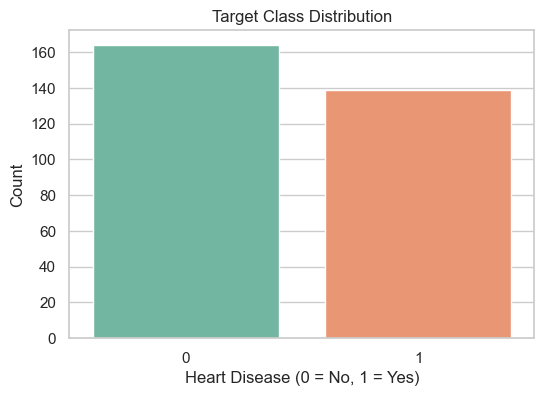

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

## 8. Numerical Feature Distributions
Visualizing the distribution of continuous numerical features using histograms.

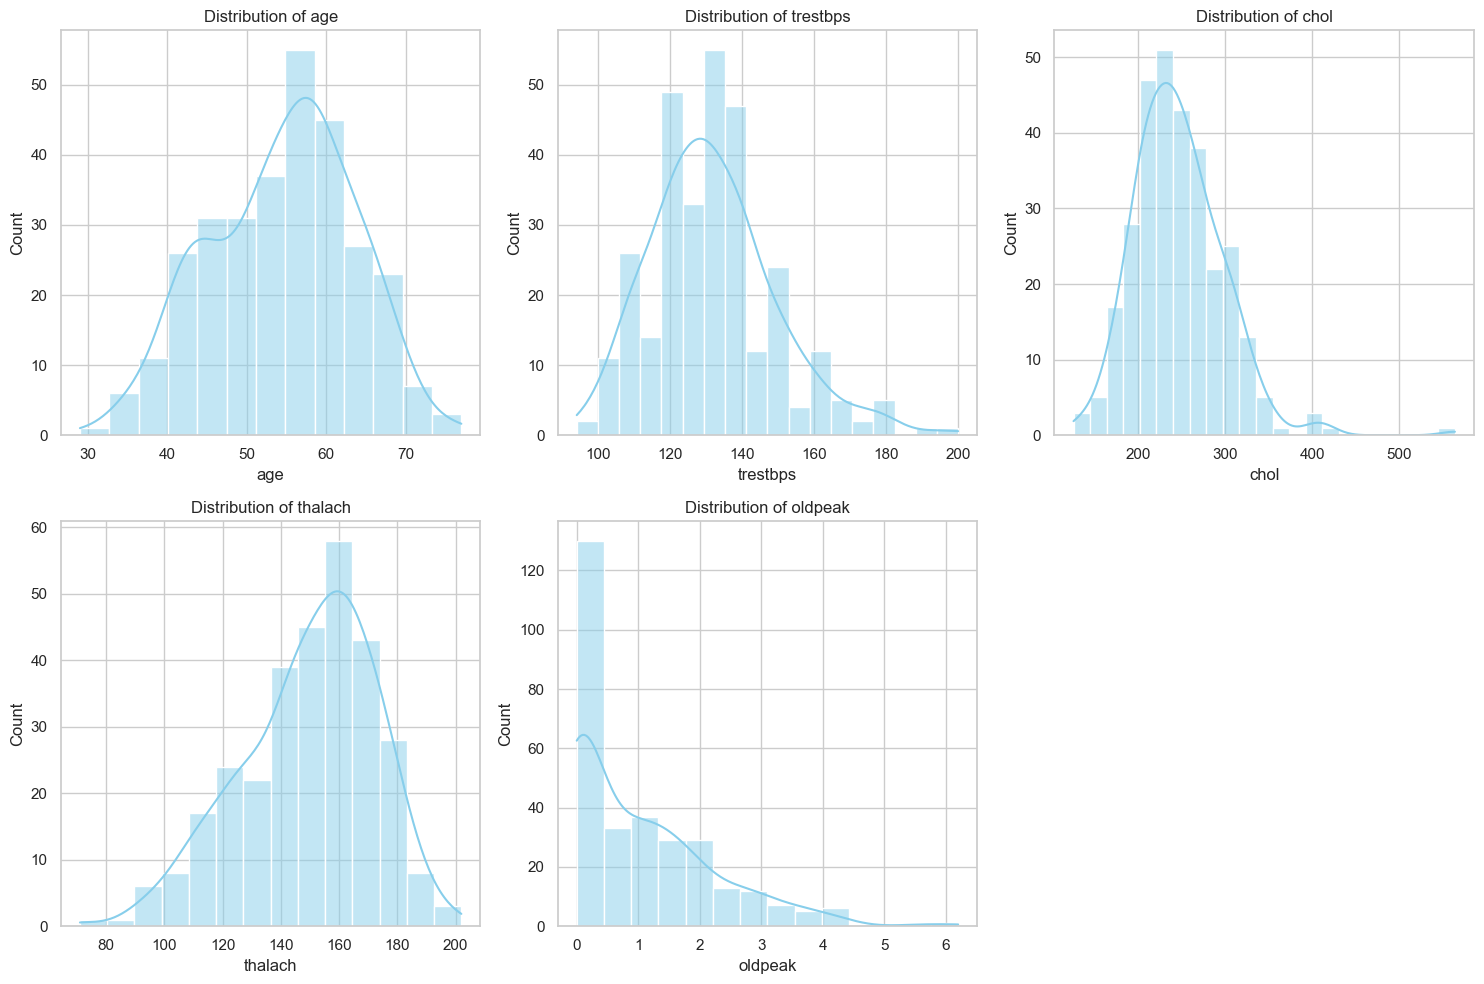

In [12]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../images/numerical_distributions.png', bbox_inches='tight')
plt.show()

## 9. Categorical Feature Distributions
Visualizing categorical features and their relationship with the target variable.

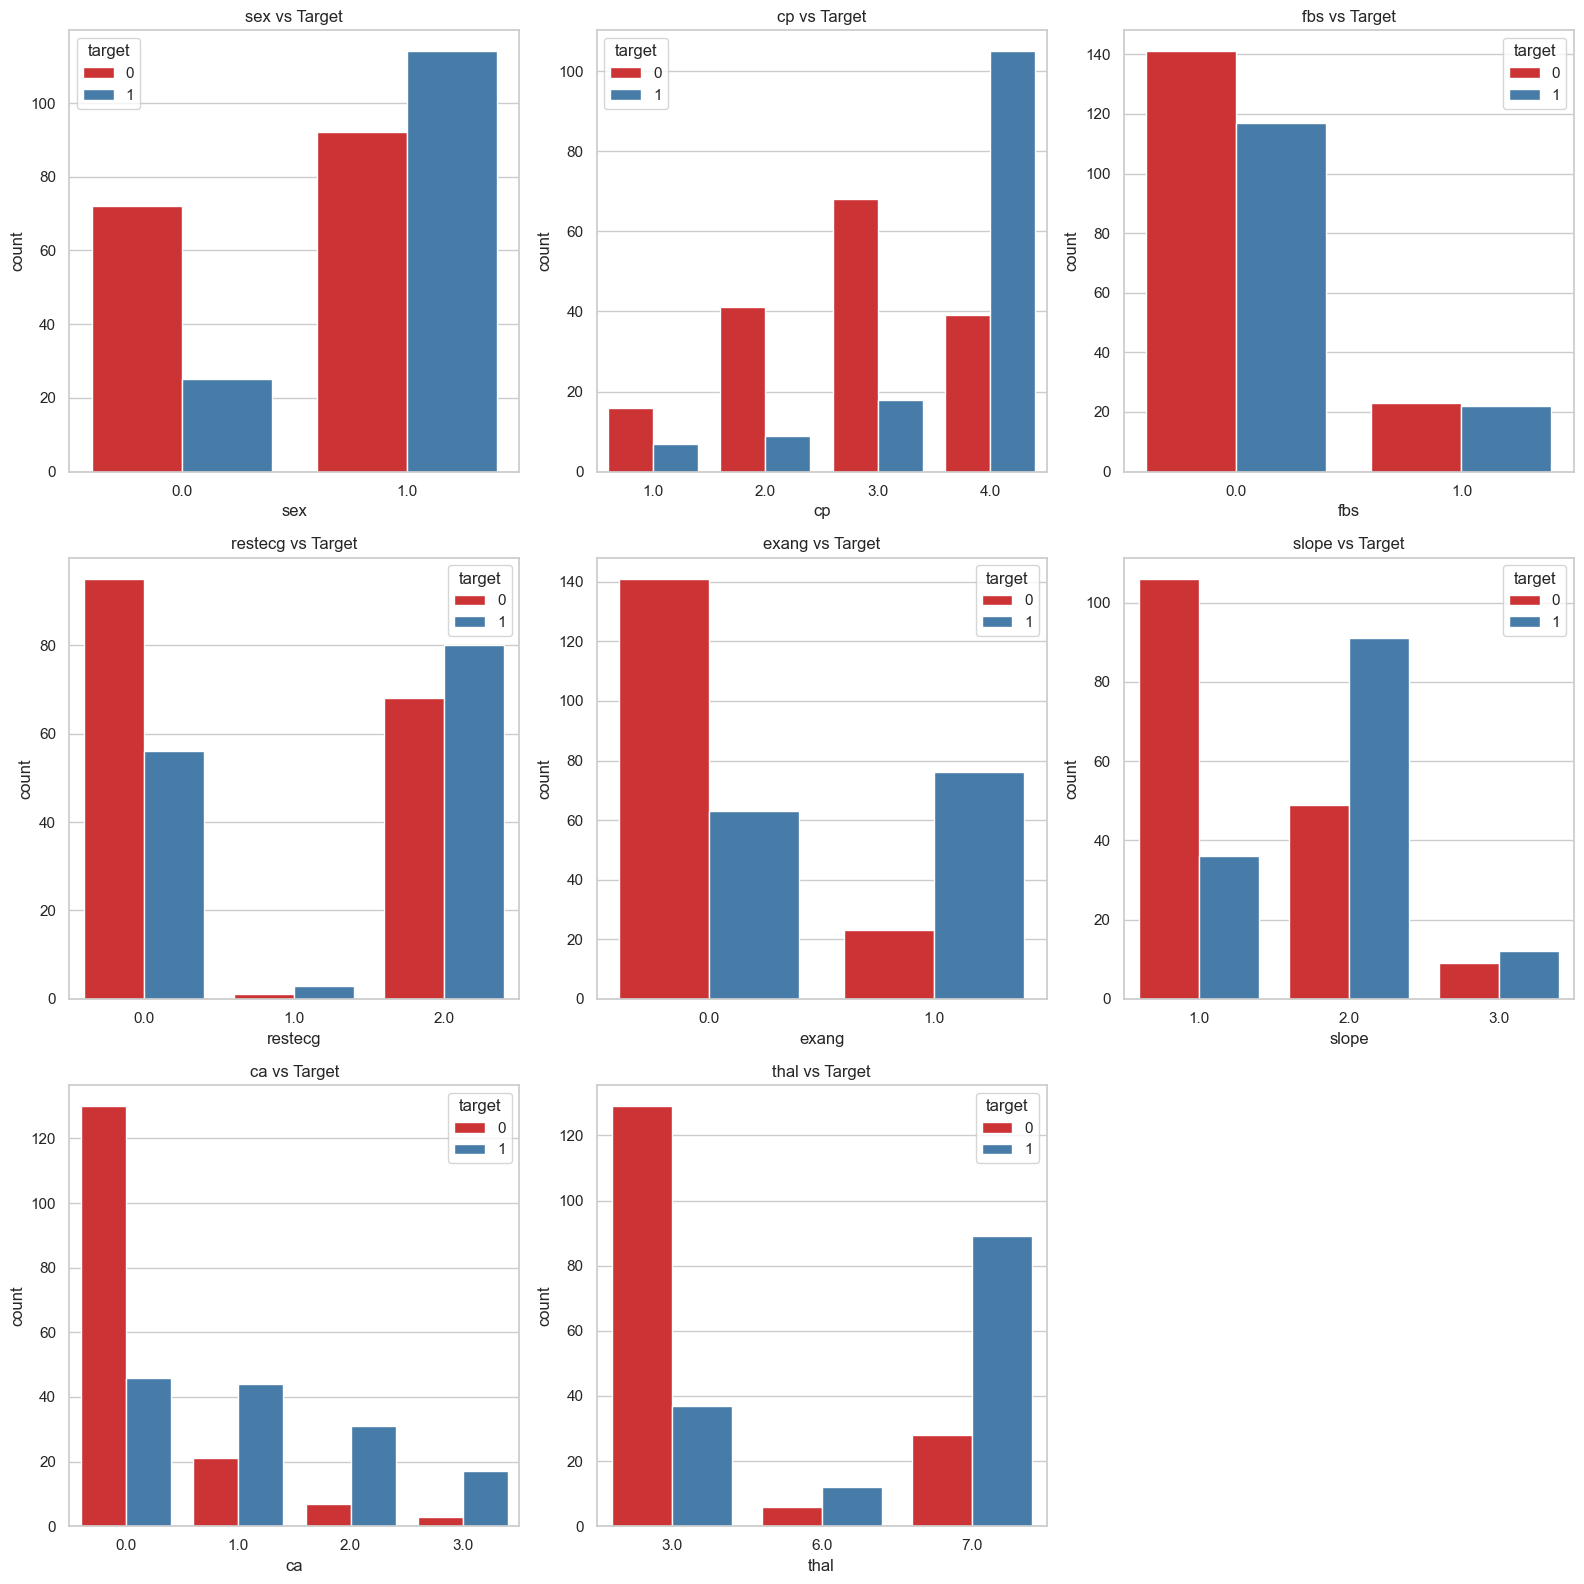

In [16]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} vs Target')

fig.delaxes(axes[8])
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

## 10. Correlation Matrix
Finding linear correlations between numerical features and the target variable.

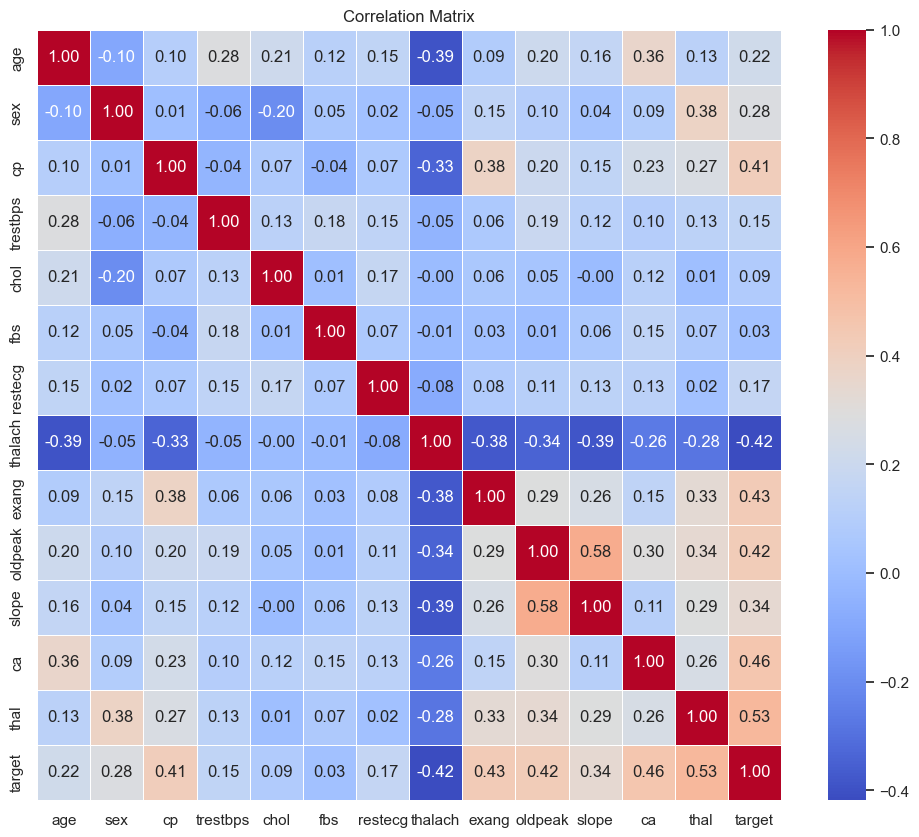

In [18]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.savefig('../images/correlation_matrix.png', bbox_inches='tight')
plt.show()

## 11. Important Feature Relationships
Exploring the relationship between Age and Max Heart Rate (thalach).

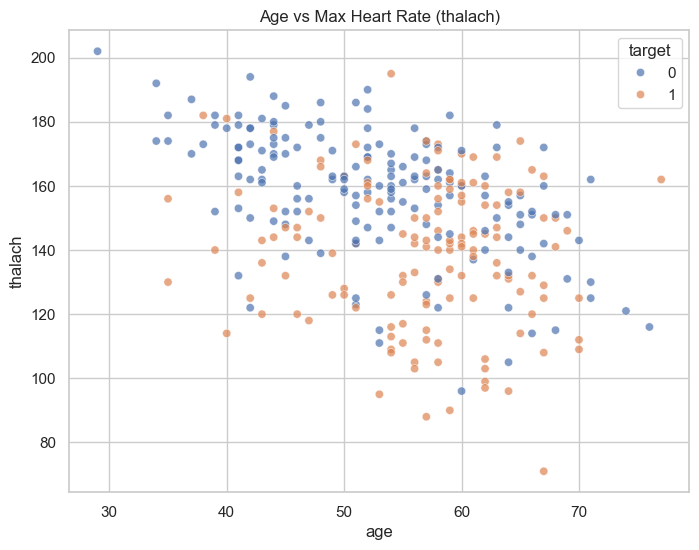

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='deep', alpha=0.7)
plt.title('Age vs Max Heart Rate (thalach)')
plt.savefig('../images/age_vs_thalach.png', bbox_inches='tight')
plt.show()

## 12. Outlier Inspection
Using boxplots to identify potential outliers in numerical features.

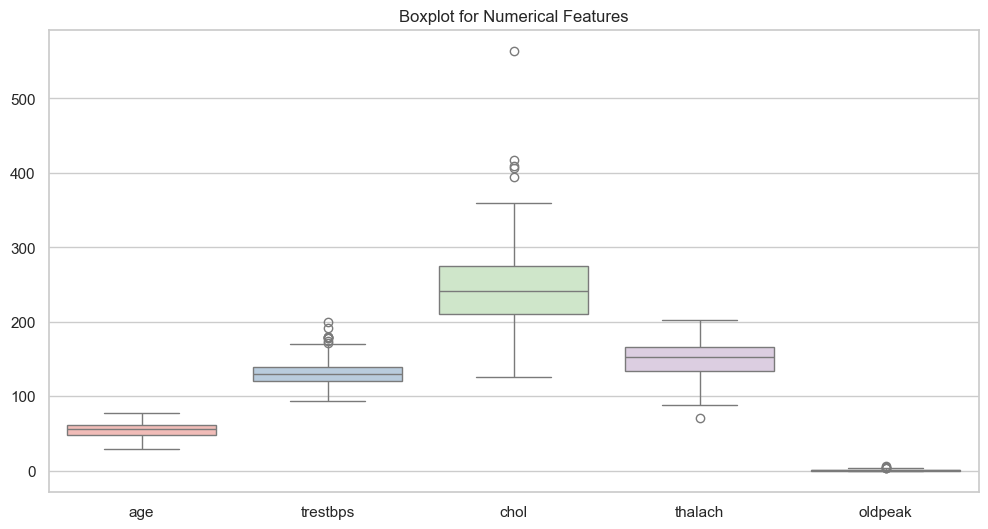

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette='Pastel1')
plt.title('Boxplot for Numerical Features')
plt.savefig('../images/outlier_inspection.png', bbox_inches='tight')
plt.show()